# Experimento 17

## Entrenamiento pipeline seleccionada modelo 1D

Replicamos la pipeline seleccionada en los entrenamientos del modelo 2D. No ha sido necesario realizar adaptaciones porque ninguna de las aumenatciones que se apliaban directamente a los espectrogramas (time_masking y frequency_masking) ha sido seleccionada.

In [1]:
from framework.framework_final import Persister, MetricsCalculator, AudioResNetModel, GSC, Preprocessor, Trainer, Evaluator, prepare_batch, plot_curves, show_image_grid, signal_grad_cam_overlays2d, signal_grad_cam_single1d
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
from typing import List, Dict, Any, Optional
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from signal_grad_cam.pytorch_cam_builder import TorchCamBuilder

I0000 00:00:1781124745.281542    7547 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781124745.312567    7547 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781124746.130108    7547 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781124746.130367    7547 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
AUDIO_PATH = Path('/mnt/data/GSC/normalized-dataset')
XTRAIN_PATH = Path('./dataframes/FASE2-X_train.csv')
XTEST_PATH = Path('./dataframes/FASE2-X_test.csv')
XVAL_PATH = Path('./dataframes/FASE2-X_val.csv')
YVAL_PATH = Path('./dataframes/FASE2-y_val.csv')
YTRAIN_PATH = Path('./dataframes/FASE2-y_train.csv')
YTEST_PATH = Path('./dataframes/FASE2-y_test.csv')
BACKGROUND_NOISES = sorted(Path(f"/mnt/data/GSC/speech_commands_v0.02/_background_noise_/").glob('*wav'))

NUM_CLASSES = 35

DEVICE = 'cuda'

# Cambios MELs
SAMPLE_RATE = 16000
N_MELS =128
N_FFT = int(768)
WIN_LENGTH = N_FFT
HOP_LENGTH = int(100)

In [3]:
final_path = '17B-modelo_1d_entrenamiento/final'
checkpoints_path = '17B-modelo_1d_entrenamiento/checkpoints'
xai_path = Path('/mnt/data/GSC/XAI/17B-modelo_1d_entrenamiento')
batch_size = 48 #El hardware a disposición no puede con más 
epochs = 20

In [4]:
%%capture
# Instanciación del framework
persister = Persister(final_path=final_path, checkpoints_path=checkpoints_path, xai_path=xai_path)
preprocessor_train = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        with_log = True,
        device = DEVICE,
        mode = "training",
        output = "waveform",
        augmentation_probs = {
            "time_shift" : 0.6,
            "speed_perturb" : 0.5,
            "random_gain" : 0.3,
            "reverb" : 0.2,
            "basic_eq_and_compress" : 0.15})


preprocessor_test = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        with_log = True,
        device = DEVICE,
        output = "waveform")
# Modelo
model1D = AudioResNetModel(dims=1, num_classes=NUM_CLASSES).get_model()
model1D.to(DEVICE)

In [5]:
# Conjuntos de datos
X_train = pd.read_csv(XTRAIN_PATH)
X_test = pd.read_csv(XTEST_PATH)
y_train = pd.read_csv(YTRAIN_PATH)
y_test = pd.read_csv(YTRAIN_PATH)
X_val = pd.read_csv(XVAL_PATH)                                                                                                          
y_val = pd.read_csv(YVAL_PATH)                                                                                                          

le = LabelEncoder()

y_encoded = le.fit_transform(y_train['keyword'])
ytest_encoded = le.transform(y_test['keyword'])
yval_encoded = le.transform(y_val['keyword'])

label_names= le.classes_

train_list = X_train['path_normalized'].tolist()                                                                                            
train_labels = y_encoded.tolist() 
val_list = X_val['path_normalized'].tolist()                                                                                            
val_labels = yval_encoded.tolist() 
test_list = X_test['path_normalized'].tolist()
test_labels = ytest_encoded.tolist()

train_dataset = GSC(file_list=train_list, labels=train_labels)
validation_dataset = GSC(file_list=val_list, labels=val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=prepare_batch, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=prepare_batch, num_workers=4)
test_dataset = GSC(test_list, test_labels)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 4)

In [6]:
trainer = Trainer(model=model1D, train_loader=train_loader, val_loader=val_loader, preprocessor=preprocessor_train, persister=persister, device=DEVICE, epochs=epochs)                        
trainer.fit(resume=False)

Epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/1544 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/221 [00:00<?, ?it/s]

Epoch 1/20
  Train - Pérdida: 2.4266, Accuracy: 0.3327, F1-score: 0.2736
  Val   - Pérdida: 22.7511, Accuracy: 0.0625, F1-score: 0.0257


Batches entrenamiento:   0%|          | 0/1544 [00:00<?, ?it/s]

...

Batches validación:   0%|          | 0/221 [00:00<?, ?it/s]

Epoch 19/20
  Train - Pérdida: 0.8876, Accuracy: 0.7536, F1-score: 0.7378
  Val   - Pérdida: 0.8888, Accuracy: 0.7588, F1-score: 0.7448


Batches entrenamiento:   0%|          | 0/1544 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/221 [00:00<?, ?it/s]

Epoch 20/20
  Train - Pérdida: 0.8784, Accuracy: 0.7552, F1-score: 0.7400
  Val   - Pérdida: 1.0431, Accuracy: 0.7164, F1-score: 0.7009


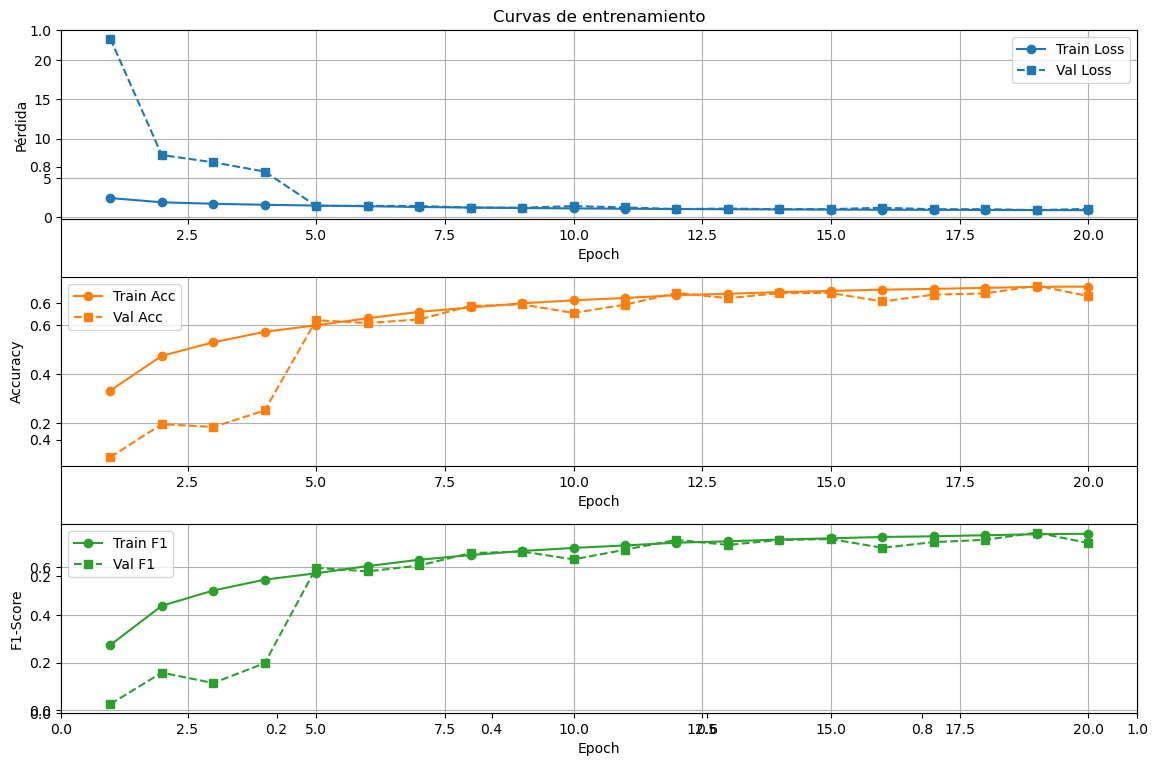

In [6]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=1, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

plot_curves(loaded_pt, 'Curvas de entrenamiento')

Se observa que este modelo aprende de forma más sostenida y no se aprecia sobreajuste.

In [7]:
df = pd.DataFrame(loaded_pt['history'])
df.index = df.index+1
with pd.option_context("display.max_rows", None):
    print(df)

    train_loss  train_acc  train_f1   val_loss   val_acc    val_f1  epoch_time
1     2.426609   0.332681  0.273594  22.751053  0.062465  0.025747  627.086909
2     1.882856   0.473820  0.437874   7.909597  0.196277  0.157788  637.496571
3     1.697870   0.528677  0.502033   6.979284  0.184937  0.114257  640.886256
4     1.566781   0.571319  0.547546   5.803205  0.252032  0.197438  641.821035
5     1.468632   0.597883  0.574334   1.421109  0.618409  0.597089  642.524478
6     1.380649   0.626203  0.604439   1.437020  0.606880  0.582233  643.190045
7     1.284085   0.652349  0.630922   1.408264  0.621622  0.606874  643.376436
8     1.215976   0.670005  0.650535   1.210055  0.676243  0.658603  643.895802
9     1.151822   0.686851  0.667746   1.199165  0.682385  0.665470  643.890458
10    1.104047   0.699229  0.680507   1.394031  0.647893  0.632442  644.133759
11    1.063374   0.708422  0.690849   1.226942  0.681440  0.673035  643.809182
12    1.021898   0.720044  0.702477   1.024074  0.72

La mejor métrica en val f1 la tenemos en la epoch 19. Cargamos ese modelo:

In [8]:
%%capture
loaded_pt = torch.load(f"{checkpoints_path}/best_checkpoint_epoch_19.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=1, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

In [9]:
# Instanciamos el evaluador y computamos métricas
evaluator = Evaluator(model=loaded_model, device=DEVICE, test_loader=test_loader, preprocessor = preprocessor_test)
confusion_matrix, precission, recall, avg_loss, accuracy, f1, support = evaluator.eval()
print("Pérdida:", avg_loss, "Accuracy:", accuracy, "F1-Score:", f1)

Batches evaluación:   0%|          | 0/221 [00:00<?, ?it/s]

Pérdida: 1.1489257167111586 Accuracy: 0.749007749007749 F1-Score: 0.7297304842296404


In [10]:
# Ratio entre f1 test y f1 en val
print("Ratio test/val F1:", f1/loaded_pt['history'].get('val_f1')[9])
print("Ratio test/val Accuracy:", accuracy/loaded_pt['history'].get('val_acc')[9])

Ratio test/val F1: 1.1538296794669078
Ratio test/val Accuracy: 1.1560676779463244


In [11]:
print("Métricas con test set:",
      "\n\nAccuracy:", accuracy, 
      "\nPrecission:", precission, 
      "\nRecall:", recall, 
      "\nPérdida media:", avg_loss, 
      "\nF1-score:", f1)

Métricas con test set: 

Accuracy: 0.749007749007749 
Precission: 0.7616104306359798 
Recall: 0.7246074656049771 
Pérdida media: 1.1489257167111586 
F1-score: 0.7297304842296404


Se trata de un modelo aún por entrenar más en profundidad, ya que el entrenamiento no ha dado muestras de estancamiento alguno. La generalización al conjunto de test es buena, ya que el ratio entre las métricas de val y test es superior a 0.9. Sin embargo, el rendimiento del modelo es aún pobre y debe entrenarse con más epochs. Esta aproximación requiere de muchos más recursos computacionales que el entrenamiento en 2D anterior. Dado el punto del entrenamiento que se está estudiando, se considera que no merece la pena estudiar la matriz de confusión. Sí evaluaremos nuestras muestras de referencia con XAI para obtener una base de referencia al aplicar la pipeline que ha dado mejores resultados con el modelo 2D. 

In [19]:
## Signal_grad_cam: Preparamos los datos
reference_samples = ['/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/left/016e2c6d_nohash_0.wav']
reference_labels = [11,19,15]

reference_dataset = GSC(reference_samples, reference_labels)
reference_loader = DataLoader(reference_dataset, batch_size = 3, shuffle = False, 
                              collate_fn = prepare_batch, num_workers = 4)

reference_targets = [11,19,15]

In [20]:
## Generamos los CAMs
target_layers = ['basicblock_list.0.conv2.conv', 'basicblock_list.1.conv2.conv',
                 'basicblock_list.2.conv2.conv', 'basicblock_list.3.conv2.conv',
                 'basicblock_list.4.conv2.conv', 'basicblock_list.5.conv2.conv',
                 'basicblock_list.6.conv2.conv', 'basicblock_list.7.conv2.conv']

explainer = "Grad-CAM"

In [21]:
%%capture
signal_grad_cam_single1d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

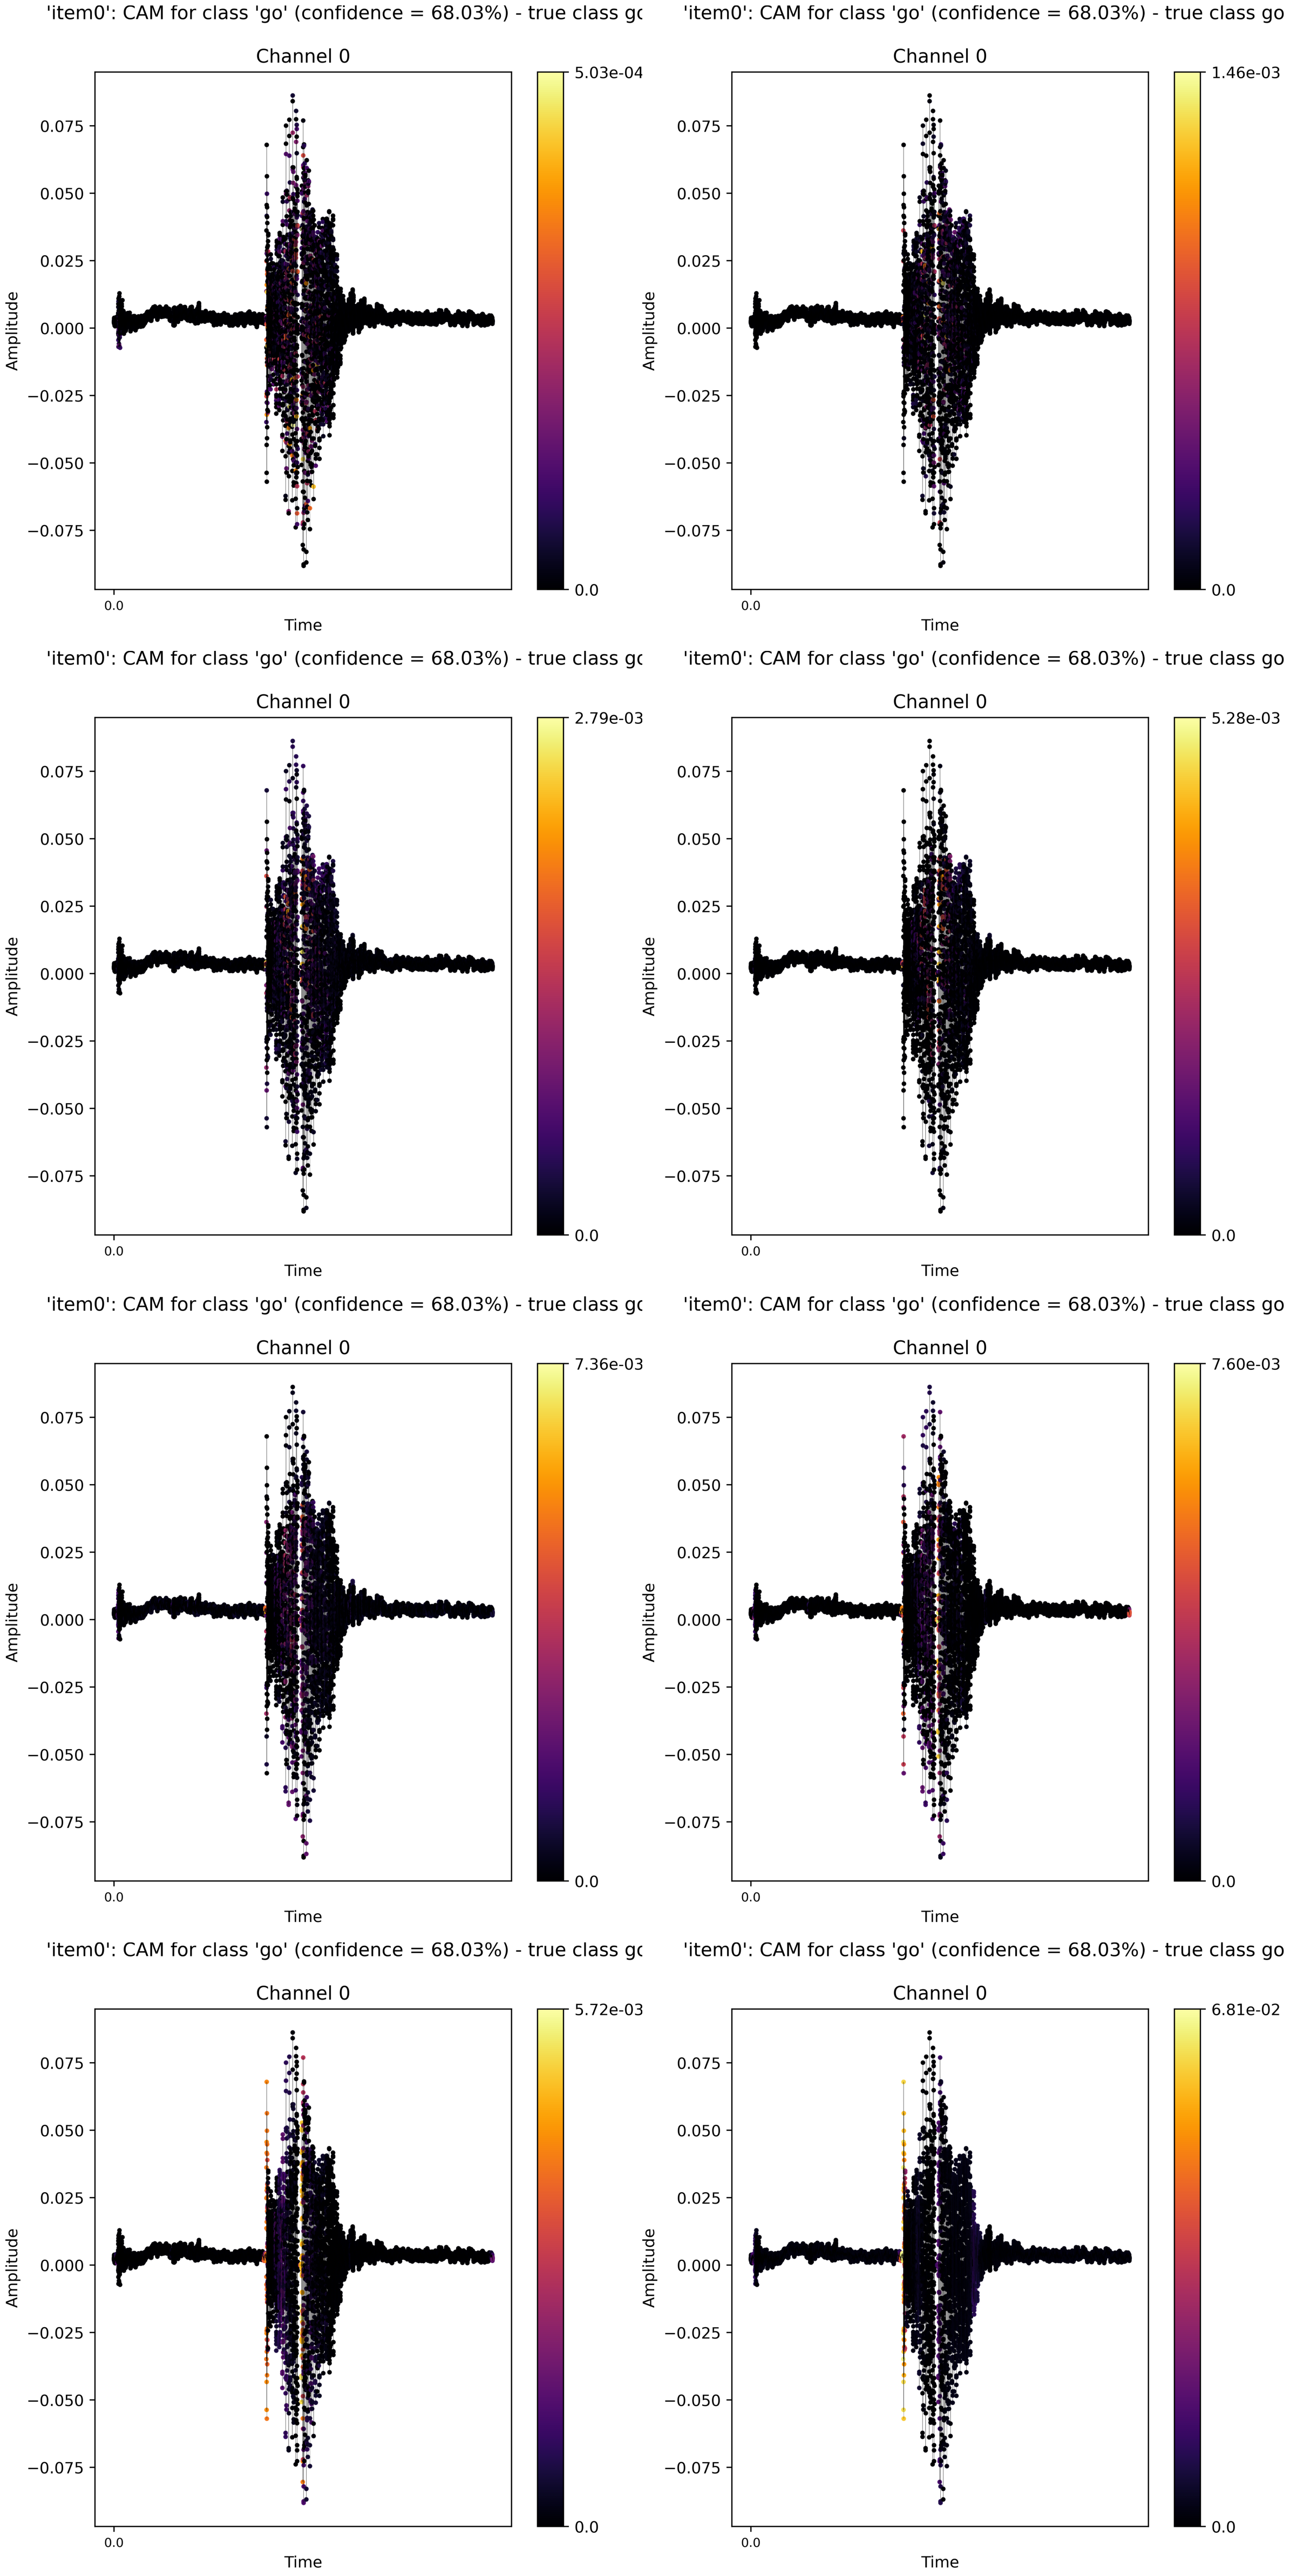

In [27]:
## Visualizamos
images_to_show = sorted(Path(f"{xai_path}/CAMs/single_channel/item0/").glob("*11.png"))
show_image_grid(images_to_show, rows=4, cols =2, figsize=(24,48))

Vamos a observar con más resolución la última capa:

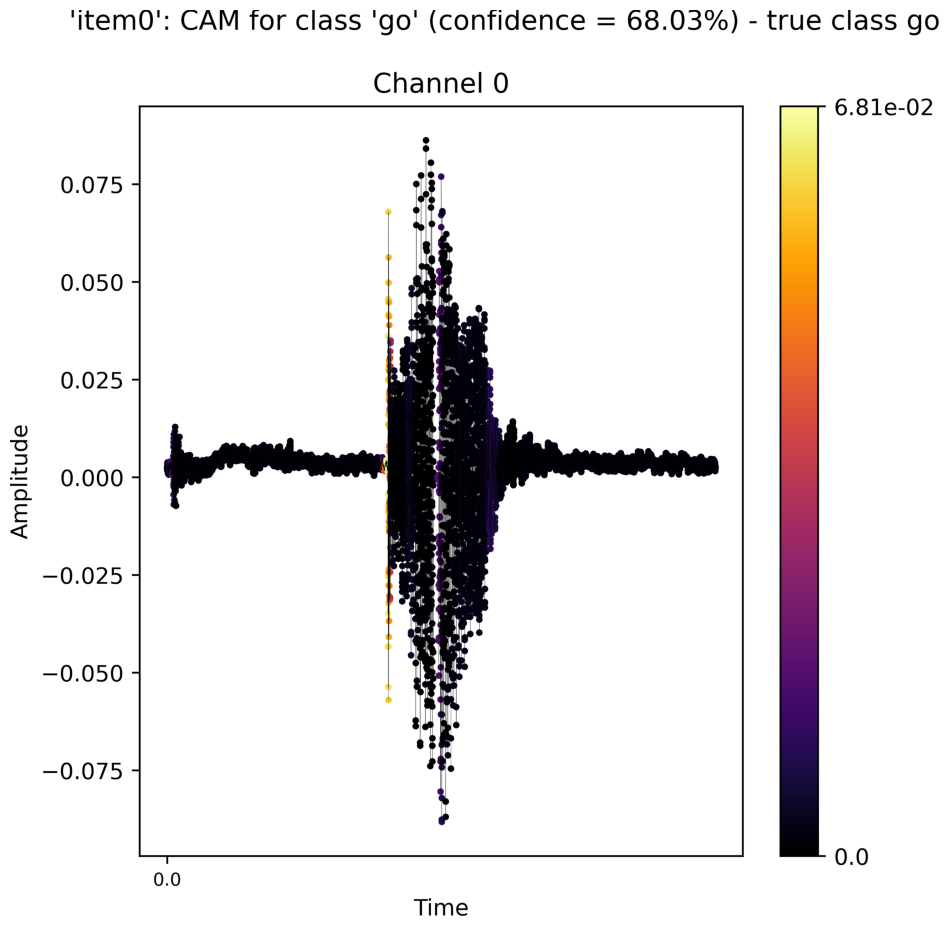

In [28]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(Path(f"{xai_path}/CAMs/single_channel/item0/channel_graphs_Grad-CAM_basicblock_list_7_conv2_conv_class11.png"))
plt.figure(figsize=(12,12))
plt.imshow(img)
plt.axis("off")
plt.show()

Vemos que la mayor atención del modelo se centra en el principio de la primera consonante, lo que constuye un criterio poco robusto y nos confirma que nos encontramos con un modelo poco maduro aún. Los feature maps de los filtros aún no contienen patrones más concluyentes con respecto a la activación de esta clase, lo que explica el bajo rendimiento del modelo en este punto.

Con respecto al coste computacional:

In [32]:
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
etimes = loaded_pt['history'].get('epoch_time')
avg_etime = sum(etimes)/len(etimes)
print(avg_etime)
model2d_etime = 195.07
print("El coste en tiempo por epoch es de", f"{avg_etime/model2d_etime:.2f}", "veces el del modelo 2d entrenado con la misma pipeline.")     

642.7747793674469
El coste en tiempo por epoch es de 3.30 veces el del modelo 2d entrenado con la misma pipeline.


El modelo no sólo necesita muchas más epochs para obtener unos resultados parecidos a ResNet18 sobre espectrogramas, sino que además cada epoch necesita el 330% del tiempo que ha costado entrenar el modelo 2d con la misma pipeline. Por esa razón, nos inclinamos por el modelo 2d para entornos de _edge computing_.